# 1: Preparation

## 1.1 Functionality Prep

### Libraries Import

In [5]:
# Libraries Import
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.layers import Input, Dense, Dropout, GRU, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)
from wrapt.importer import when_imported

### Functions

In [12]:
# Duplicates Function
import difflib
def duplicates(x):
  if x.duplicated().sum() > 0:
    print(f'There are {x.duplicated().sum()} duplicated rows')
    view_dp = input('Review duplicated rows? (y/n)')
    if view_dp.lower().strip() == 'y':
      display(x[x.duplicated()])
    else:
      print('Not reviewing duplicated rows')
  else:
    check_dp = input('There are no duplicated rows. Do you want to review? (y/n)')
    if check_dp.lower().strip() == 'y':
      review_subset = input(f'Review from: {x.columns.tolist()}:')
      review_dp = x.groupby(review_subset).filter(lambda f: len(f) > 1).sort_values(by=review_subset)
      display(review_dp)
    else:
      print('Not reviewing data')

In [2]:
# Missing Values Function
def inspectna(x):
  nas = pd.isna(x).any().reset_index().rename(columns = {'index':'column', 0:'missing'})
  for i, cols, val in zip(range(len(x.columns)), x.columns, x.values.T):
      for j in val:
          if nas.iloc[i, 1] == True:
              break
          elif j == cols:
              nas.iloc[i, 1] = True
  regna = r'(?i)^\s*(?:na|n/?a|nan|null|none|unknown|not\s+available|)\s*$'
  masked = x.astype('string').apply(lambda a: a.str.match(regna, na=False))
  if nas[nas.columns[1]].sum() == 0:
    if masked.any().any():
      dictna = []
      for i, j in zip(masked.columns, masked.any()):
        if j == True:
          dictna.append(i)
      print(f'Missing values at {dictna}')
      checkna = input('Do you want to review? y/n')
      if checkna.lower().strip() == 'y':
        label_as_value = (x == x.columns)
        display(x[(pd.isna(x) | masked | label_as_value).any(axis=1)])
    else:
      return nas
  else:
    dictna = []
    for i, j in zip(nas[nas.columns[0]], nas[nas.columns[1]]) :
      if j == 1:
        dictna.append(i)
    if masked.any().any():
      for i, j in zip(masked.columns, masked.any()):
        if j == True:
          dictna.append(i)
    print(f'Missing values at {set(dictna)}')
    checkna = input('Do you want to review? y/n')
    if checkna.lower().strip() == 'y':
        label_as_value = (x == x.columns)
        display(x[(pd.isna(x) | masked | label_as_value).any(axis=1)])

In [3]:
# Describe Outliers Function
def describe_outliers(df):
    outliers_desc = []

    for col in df.select_dtypes(include='number').columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        LB = Q1 - 1.5 * IQR
        UB = Q3 + 1.5 * IQR

        outliers = df[(df[col] < LB) | (df[col] > UB)]
        count = len(outliers)
        pct = (count/len(df)) * 100
        max_val = df[col].max()
        deviation = (max_val / UB) if UB > 0 else 0

        outliers_desc.append({
            'Feature': col,
            'Count': count,
            'Percentage': f"{pct:.2f}%",
            'Severity_Score': deviation
        })

    return pd.DataFrame(outliers_desc).sort_values(by='Severity_Score', ascending=False)

## 1.2 Dataset Import

In [6]:
# Load All Monthly Sales Data
months = [
    'january', 'february', 'march', 'april',
    'may', 'june', 'july', 'august',
    'september', 'october', 'november', 'december']

df_2019 = [pd.read_csv(f'C:/Users/ASUS/PyCharmMiscProject/Dibimbing/sales_data_{m}_2019.csv') for m in months]

In [7]:
# Append Monthly Sales Data
df = pd.concat(df_2019, ignore_index=True)

## 1.3 Exploratory Data Analysis

### Preview

In [8]:
# Preview
df.head(5)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"


### Information

In [9]:
# Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


### Unique Values

In [10]:
# Unique Values
for i in df.columns:
    print(i, df[i].nunique())

Order ID 178438
Product 20
Quantity Ordered 10
Price Each 24
Order Date 142396
Purchase Address 140788


### Duplicates

In [13]:
# Check Duplicates
duplicates(df)

There are 1162 duplicated rows


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
678,NaN,NaN,NaN,NaN,NaN,NaN
797,NaN,NaN,NaN,NaN,NaN,NaN
875,142071,AA Batteries (4-pack),1,3.84,01/17/19 23:02,"131 2nd St, Boston, MA 02215"
876,NaN,NaN,NaN,NaN,NaN,NaN
1102,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
...,...,...,...,...,...,...
185481,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
185729,NaN,NaN,NaN,NaN,NaN,NaN
185925,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
185955,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


**Findings**
* There are 1162 duplicated rows that includes identified missing values rows, such as 'key' as 'values' and actual NaN rows.

In [14]:
# Duplicates Length
df.duplicated().sum()/df.shape[0] * 100

np.float64(0.6218892159486219)

In [15]:
# Drop Duplicates
df.drop_duplicates(inplace=True)

In [16]:
# Review Duplicates Length
df.duplicated().sum()/df.shape[0] * 100

np.float64(0.0)

### Missing Values

In [17]:
# Check Missing Values
inspectna(df)

Missing values at {'Order Date', 'Product', 'Price Each', 'Order ID', 'Quantity Ordered', 'Purchase Address'}


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
664,NaN,NaN,NaN,NaN,NaN,NaN
1073,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


**Findings**
* There are missing values that are not identified prior in duplicates, indicating their type as 'string' which regex successfully targeted.
* Additionally, since missing values such as 'key' as 'values' are identified in the duplicates review, there is a chance that such values are still present in the dataset and not eliminated due to them not in a duplicated rows condition.

In [509]:
# Check Mismatched Values in Key
for i in df.columns:
    display(df[i].value_counts())

Order ID
160873    5
165665    4
194253    4
296353    4
196615    4
         ..
141251    1
141252    1
141253    1
141254    1
141235    1
Name: count, Length: 178438, dtype: int64

Product
USB-C Charging Cable          21859
Lightning Charging Cable      21610
AAA Batteries (4-pack)        20612
AA Batteries (4-pack)         20558
Wired Headphones              18849
Apple Airpods Headphones      15525
Bose SoundSport Headphones    13298
27in FHD Monitor               7498
iPhone                         6840
27in 4K Gaming Monitor         6225
34in Ultrawide Monitor         6174
Google Phone                   5522
Flatscreen TV                  4794
Macbook Pro Laptop             4721
ThinkPad Laptop                4126
20in Monitor                   4098
Vareebadd Phone                2065
LG Washing Machine              666
LG Dryer                        646
Product                           1
Name: count, dtype: int64

Quantity Ordered
1                   168291
2                    13321
3                     2920
4                      806
5                      236
6                       80
7                       24
8                        5
9                        3
Quantity Ordered         1
Name: count, dtype: int64

Price Each
11.95         21859
14.95         21610
2.99          20612
3.84          20558
11.99         18849
150           15426
99.99         13298
149.99         7498
700            6802
389.99         6225
379.99         6174
600            5487
300            4774
1700           4699
999.99         4126
109.99         4098
400            2056
600.0          1347
150.0            99
700.0            38
1700.0           22
300.0            20
400.0             9
Price Each        1
Name: count, dtype: int64

Order Date
12/15/19 20:16    8
12/11/19 13:24    7
10/30/19 21:28    7
04/02/19 13:24    7
11/14/19 19:43    6
                 ..
12/23/19 18:46    1
12/18/19 08:29    1
12/14/19 23:30    1
12/03/19 05:50    1
12/23/19 14:08    1
Name: count, Length: 142396, dtype: int64

Purchase Address
193 Forest St, San Francisco, CA 94016    9
279 Sunset St, San Francisco, CA 94016    8
223 Elm St, Los Angeles, CA 90001         8
550 Cherry St, San Francisco, CA 94016    7
716 5th St, San Francisco, CA 94016       7
                                         ..
440 Cedar St, Portland, OR 97035          1
471 Center St, Los Angeles, CA 90001      1
414 Walnut St, Boston, MA 02215           1
220 9th St, Los Angeles, CA 90001         1
385 11th St, Atlanta, GA 30301            1
Name: count, Length: 140788, dtype: int64

**Findings**
* 'Product', 'Quantity Ordered', 'Price Each' appears in the value counts having their count as 1.
* Since their numbers are minuscule, it's more appropriate to drop than imputing these values.

In [510]:
# Drop Missing Values
df.dropna(inplace=True)

for i in df.columns:
    df.drop(df[df[i] == i].index, inplace=True)

In [511]:
# Review Mismatched Values in Key
for i in df.columns:
    display(df[i].value_counts())

Order ID
160873    5
196615    4
194253    4
296353    4
212334    4
         ..
141250    1
141251    1
141252    1
141253    1
141239    1
Name: count, Length: 178437, dtype: int64

Product
USB-C Charging Cable          21859
Lightning Charging Cable      21610
AAA Batteries (4-pack)        20612
AA Batteries (4-pack)         20558
Wired Headphones              18849
Apple Airpods Headphones      15525
Bose SoundSport Headphones    13298
27in FHD Monitor               7498
iPhone                         6840
27in 4K Gaming Monitor         6225
34in Ultrawide Monitor         6174
Google Phone                   5522
Flatscreen TV                  4794
Macbook Pro Laptop             4721
ThinkPad Laptop                4126
20in Monitor                   4098
Vareebadd Phone                2065
LG Washing Machine              666
LG Dryer                        646
Name: count, dtype: int64

Quantity Ordered
1    168291
2     13321
3      2920
4       806
5       236
6        80
7        24
8         5
9         3
Name: count, dtype: int64

Price Each
11.95     21859
14.95     21610
2.99      20612
3.84      20558
11.99     18849
150       15426
99.99     13298
149.99     7498
700        6802
389.99     6225
379.99     6174
600        5487
300        4774
1700       4699
999.99     4126
109.99     4098
400        2056
600.0      1347
150.0        99
700.0        38
1700.0       22
300.0        20
400.0         9
Name: count, dtype: int64

Order Date
12/15/19 20:16    8
10/30/19 21:28    7
12/11/19 13:24    7
04/02/19 13:24    7
12/12/19 22:10    6
                 ..
12/18/19 08:29    1
12/14/19 23:30    1
12/03/19 05:50    1
12/23/19 14:08    1
12/13/19 07:25    1
Name: count, Length: 142395, dtype: int64

Purchase Address
193 Forest St, San Francisco, CA 94016    9
279 Sunset St, San Francisco, CA 94016    8
223 Elm St, Los Angeles, CA 90001         8
550 Cherry St, San Francisco, CA 94016    7
727 9th St, San Francisco, CA 94016       7
                                         ..
363 Spruce St, Austin, TX 73301           1
440 Cedar St, Portland, OR 97035          1
471 Center St, Los Angeles, CA 90001      1
414 Walnut St, Boston, MA 02215           1
185 Maple St, Portland, OR 97035          1
Name: count, Length: 140787, dtype: int64

### Handle Datatypes

In [512]:
# Handle Datatypes
df['Quantity Ordered'] = df['Quantity Ordered'].astype('int64')
df['Price Each'] = df['Price Each'].astype('float64')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%y %H:%M')

In [513]:
# Rename Feature
df.rename(columns={'Price Each' : 'Price', 'Quantity Ordered' : 'Quantity'}, inplace=True)

In [514]:
# Review Datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185686 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185686 non-null  object        
 1   Product           185686 non-null  object        
 2   Quantity          185686 non-null  int64         
 3   Price             185686 non-null  float64       
 4   Order Date        185686 non-null  datetime64[ns]
 5   Purchase Address  185686 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 9.9+ MB


### Feature Engineering

In [515]:
# Create Revenue Feature
df['Revenue'] = df['Quantity'] * df['Price']

In [516]:
# Extract City and Postal Code
df['City'] = df['Purchase Address'].str.split(',').str[1].str.strip()
df['Postal Code'] = df['Purchase Address'].str.split(',').str[2].str.strip().str.split().str[-1]

In [517]:
# Review
df.head(5)

,Order ID,Product,Quantity,Price,Order Date,Purchase Address,Revenue,City,Postal Code
0,141234,iPhone,1,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215",700.00,Boston,02215
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035",14.95,Portland,97035
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016",23.98,San Francisco,94016
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001",149.99,Los Angeles,90001
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301",11.99,Austin,73301


### Data Continuity Check

In [518]:
# Resample Data in Daily Aggregate of Orders
df_ts = df[df['Order Date'].dt.year == 2019].set_index('Order Date').sort_index()
ts_orders = df_ts.resample('D')['Order ID'].nunique()

**Findings**:
* Data has been sorted ascendingly from the oldest to newest calendar-wise date, and every transaction in the same date has been aggregated.
* However, since there are duplicates and missing values that are removed from the dataset, there is a possibility that date continuity might be interrupted, leading to gaps in the date range. Therefore, it must be examined whether such possibility is happening or not.

In [519]:
# Missing Dates Check
full_range = pd.date_range(start=ts_orders.index.min(), end=ts_orders.index.max(), freq='D')
missing_dates = full_range.difference(ts_orders.index)
print(f"Missing Dates: {len(missing_dates)}")
print(missing_dates)

Missing Dates: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


**Findings**:
* It has been confirmed that there are no missing dates, meaning that data continuity is preserved well despite duplicates and missing values are handled by removing them.

### Monthly Trend Plot

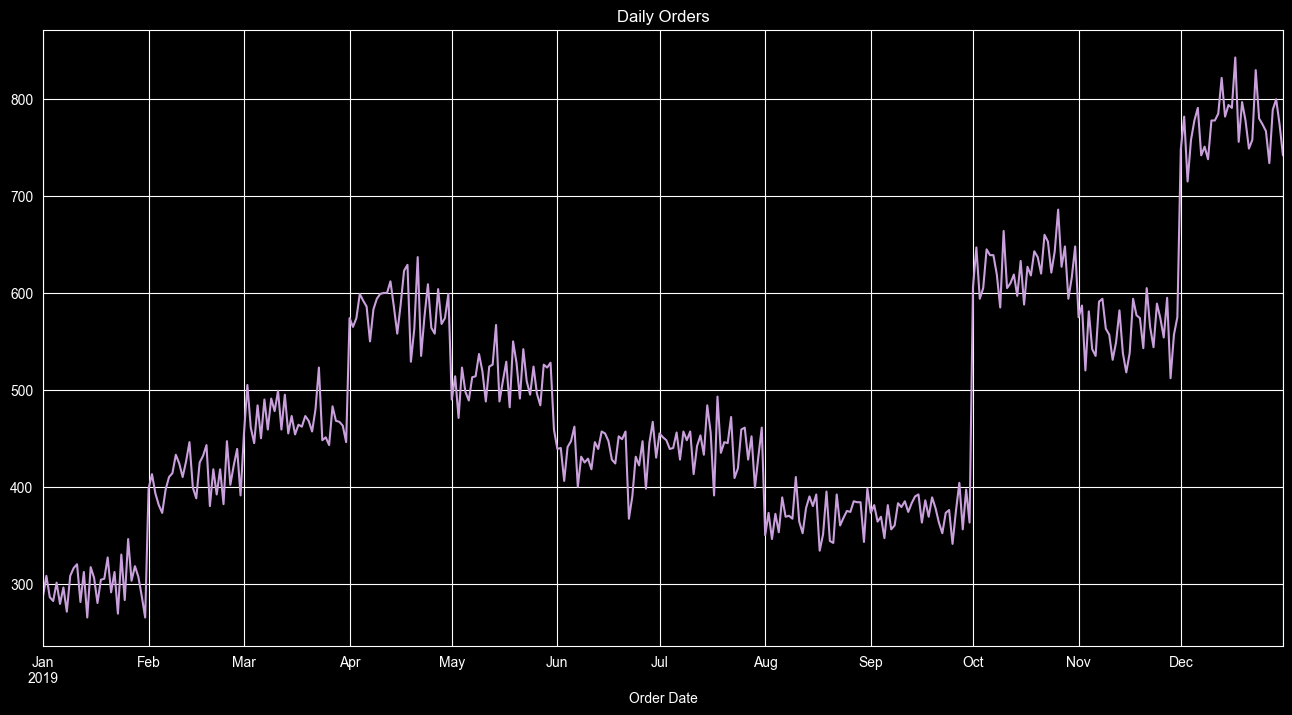

In [520]:
# Monthly Trend Plot
plt.figure(figsize = (16, 8))
ts_orders.plot(title='Daily Orders', color='#C9A0DC')
plt.show()

**Findings**:
* There's a positive trend of growth throughout 2019, from an average records of 300 orders in January to 700-800 in December.
* From the end of September to the start of October, there's a spike from 400 to 600 orders, with a similar pattern is shown from the end of November to the start of December spiking from 600 to ~750 orders. This could indicate an effect of marketing strategy, or rather a dataset problem.

### Decomposition Plot

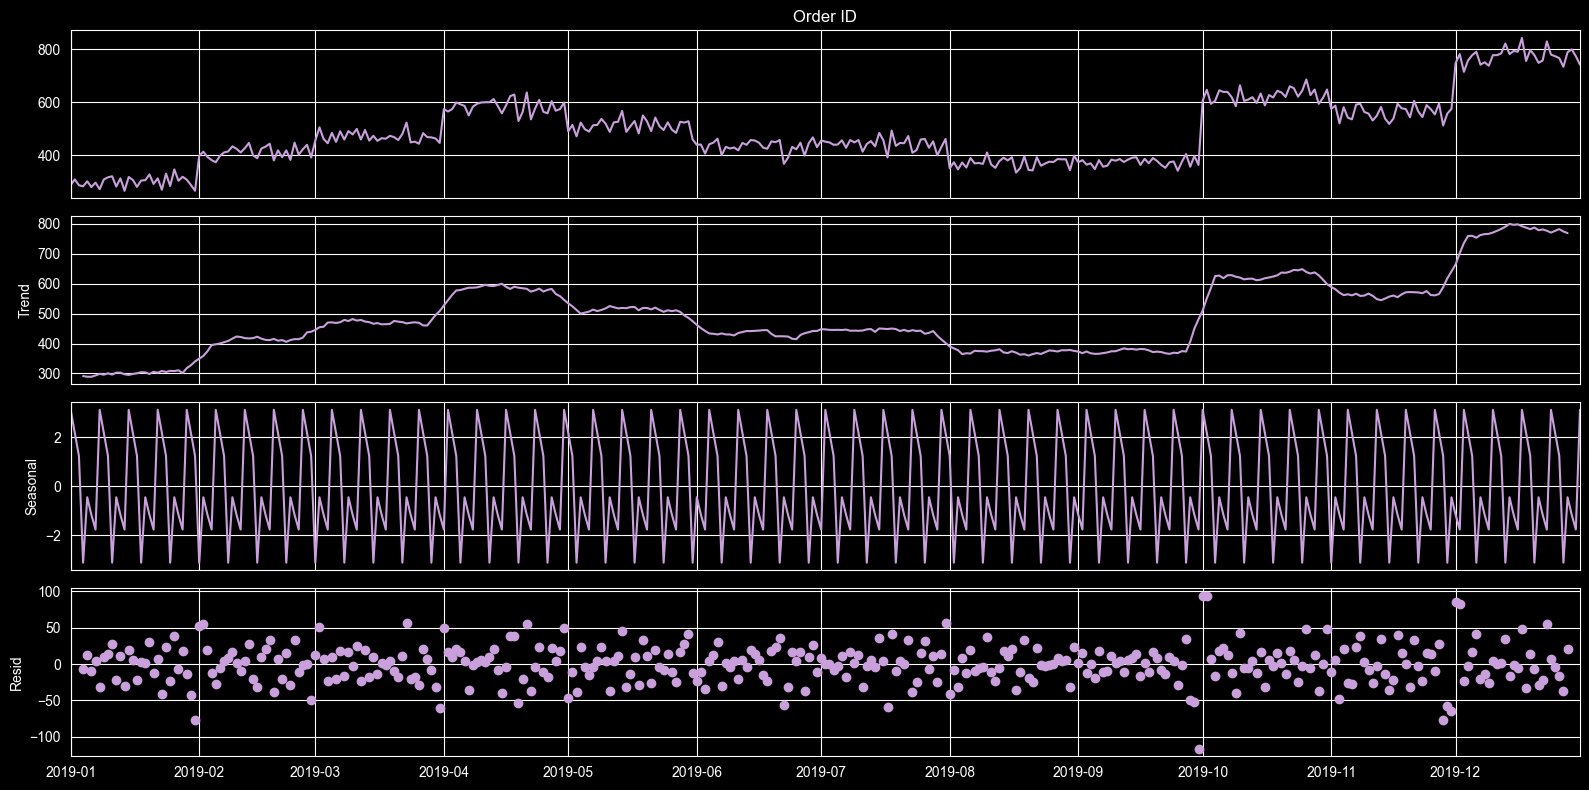

In [521]:
# Decomposition
decomp = seasonal_decompose(ts_orders, model='additive', period=7)
fig = decomp.plot()
for ax in fig.axes:
    ax.lines[0].set_color('#C9A0DC')
fig.set_size_inches(16, 8)
plt.tight_layout()
plt.show()

**Findings**:
* **Trend**: Orders are growing in Q1 to the start of Q2, then going down throughout mid-Q2 to the end of Q3 before going up again through the Q4.
* **Seasonality**: There's a weekly seasonality pattern with consistent amplitudes with one day having the highest volume than the others.
* **Residuals** : Data's abnormalities are scattered randomly and near the 0 axis, with the periods in October and December are having the abnormalities quite far from the 0 axis, consistent with the noticed trend where there are significant spikes in both periods.

### Stationarity Test

In [522]:
# Stationarity Test
result_quantity = adfuller(ts_orders.dropna())
print('ADF Statistic: %f' % result_quantity[0])
print('p-value: %f' % result_quantity[1])

ADF Statistic: -1.131085
p-value: 0.702518


**Findings**:
* With an Augmented Dickey-Fuller test p-value result of 0.702518 (> 0.05), the time series data is found to be non-stationary, meaning the mean and variance of the series change over time, consistent with the non-linear pattern exhibited on the trend plot.

### Outlier Handling

In [523]:
# Outliers
resid = decomp.resid.dropna()

# Z-Score
z_scores = np.abs(stats.zscore(resid))
outliers = resid[z_scores > 3]
print(outliers)

Order Date
2019-09-30   -116.229053
2019-10-01     93.165905
2019-10-02     93.835373
2019-12-01     85.311563
2019-12-02     81.913804
Name: resid, dtype: float64


**Findings**:
* 5 outliers are detected on Sep-30, Oct-01, Oct-02, Dec-01, and Dec-29 via Z-score on residuals. Since the outliers date are identical to the abnormalities in the trend being two set of spikes, therefore these outliers are retained.|

# 2: Business Questions

## Question 1
Hitunglah total revenue, jumlah order, dan jumlah barang yang terjual sepanjang tahun 2019. Selain itu, hitung rata-rata jumlah barang yang dibeli per transaksi dan rata-rata spending per transaksi.

In [524]:
# Calculate Each Independently
display(
    f"Total Yearly Revenue : {df['Revenue'].sum()}",
    f"Total Yearly Order : {df['Order ID'].nunique()}",
    f"Total Yearly Quantity : {df['Quantity'].sum()}",
    f"Average Quantity per Transaction : {df.groupby('Order ID')['Quantity'].sum().mean():.2f}",
    f"Average Spending per Transaction : {df.groupby('Order ID')['Revenue'].sum().mean():.2f}")

'Total Yearly Revenue : 34465537.94'

'Total Yearly Order : 178437'

'Total Yearly Quantity : 208812'

'Average Quantity per Transaction : 1.17'

'Average Spending per Transaction : 193.15'

## Question 2
* Hitunglah jumlah order yang diperoleh dengan rentang waktu berikut:
    * Harian
    * Mingguan
    * Bulanan


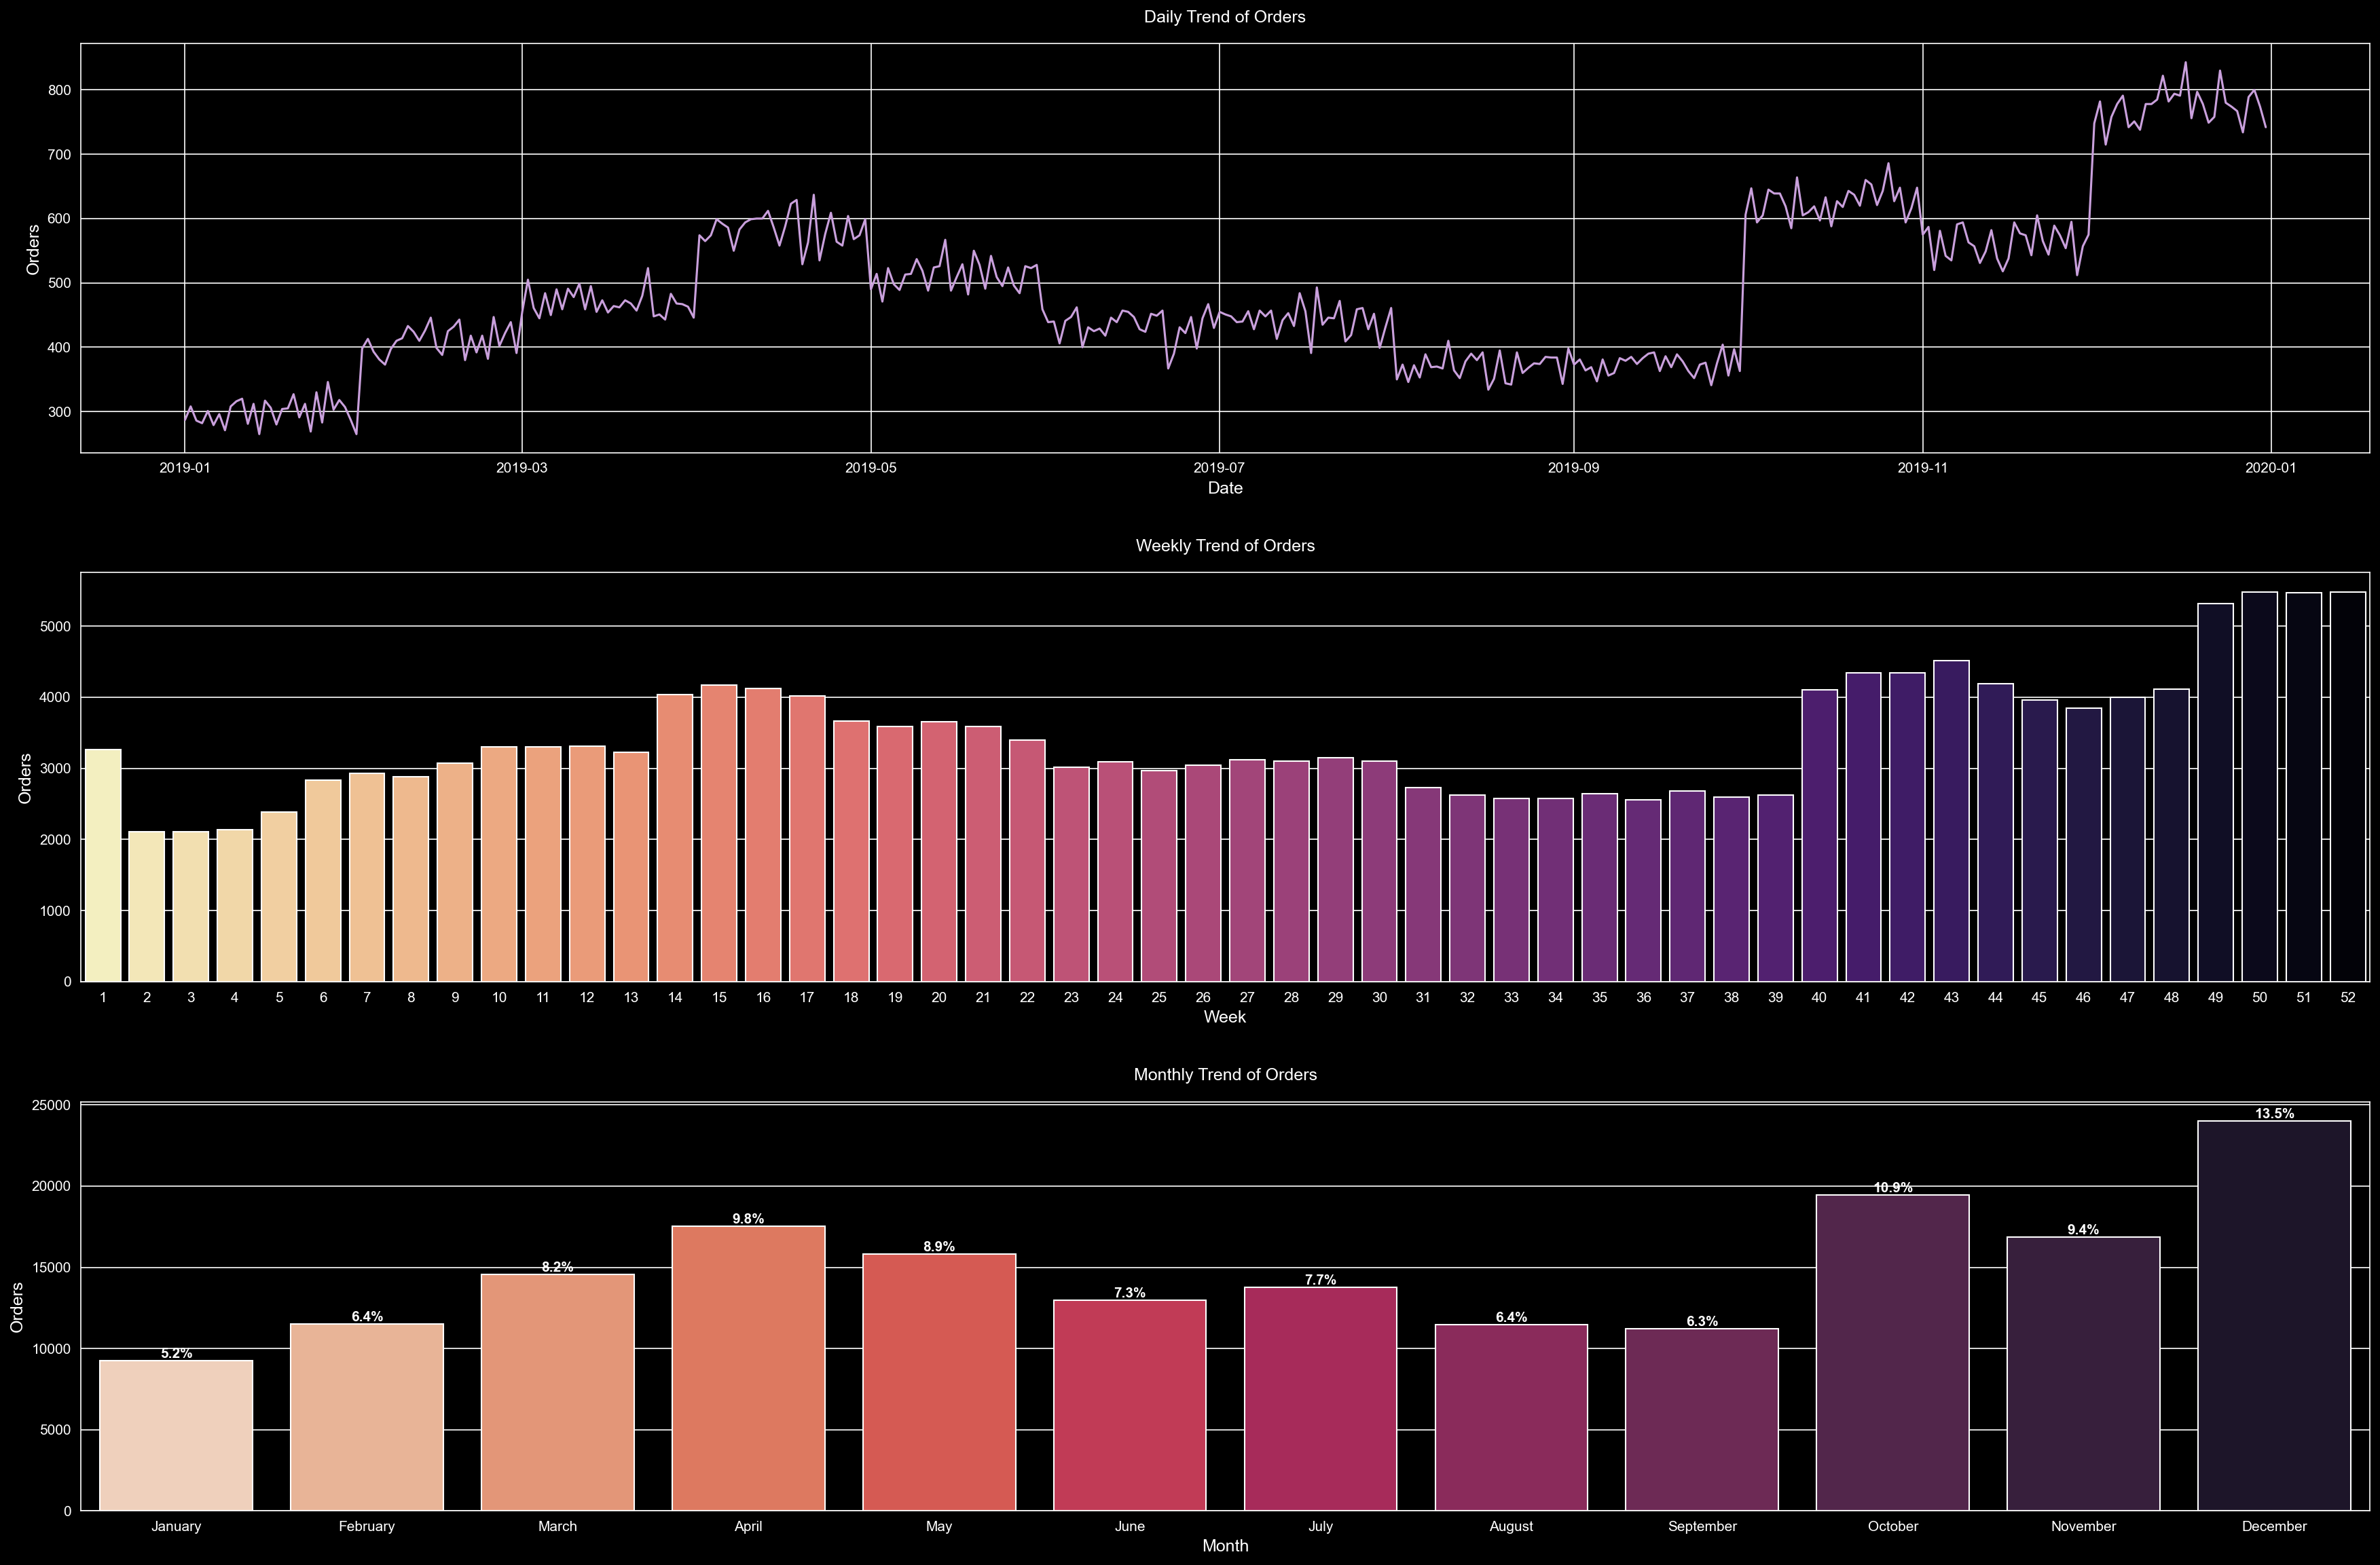

In [525]:
# Create Daily, Weekly, and Monthly Groups of Orders Sum

# Daily Orders
df_daily = df[df['Order Date'].dt.year == 2019].groupby(df['Order Date'].dt.date)['Order ID'].nunique().reset_index().rename(columns={'Order ID' : 'Total Orders'})
df_daily['Order Date'] = pd.to_datetime(df_daily['Order Date'], format='%Y-%m-%d')

# Weekly Orders
df_weekly = df_daily.groupby(df_daily['Order Date'].dt.isocalendar().week)['Total Orders'].sum().reset_index().rename(columns={'week':'Week'})

# Monthly Orders
df_daily['MonthOrd'] = df_daily['Order Date'].dt.month
df_daily['Month'] = df_daily['Order Date'].dt.month_name()
df_monthly = df_daily.groupby(['MonthOrd', 'Month'])['Total Orders'].sum().reset_index().sort_values(by='MonthOrd', ascending=True)
df_daily.drop(['Month', 'MonthOrd'], axis=1, inplace=True)
df_monthly = df_monthly.drop('MonthOrd', axis=1)
df_monthly['Percentage'] = df_monthly['Total Orders']/df_monthly['Total Orders'].sum() * 100

fig, axes = plt.subplots(3, 1, figsize=(24, 16), dpi=150, frameon=True)

# Daily Plot
sns.lineplot(data=df_daily, x='Order Date', y='Total Orders', ax=axes[0], color='#C9A0DC')
axes[0].set_title(f'Daily Trend of Orders', fontsize=12, pad=15)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Orders', fontsize=12)

# Weekly Plot
sns.barplot(data=df_weekly, x='Week', y='Total Orders', ax=axes[1], palette='magma_r')
axes[1].set_title(f'Weekly Trend of Orders', fontsize=12, pad=15)
axes[1].set_xlabel('Week', fontsize=12)
axes[1].set_ylabel('Orders', fontsize=12)

# Monthly Plot
sns.barplot(data=df_monthly, x='Month', y='Total Orders', ax=axes[2], palette='rocket_r')
axes[2].set_title(f'Monthly Trend of Orders', fontsize=12, pad=15)
axes[2].set_xlabel('Month', fontsize=12)
axes[2].set_ylabel('Orders', fontsize=12)
for i, (orders, pct) in enumerate(zip(df_monthly['Total Orders'], df_monthly['Percentage'])):
    axes[2].text(i, orders, f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot All
plt.tight_layout(pad=3)
plt.show()

## Question 3
* Tim marketing ingin mengetahui produk apa saja yang paling sering dibeli dalam 1 tahun terakhir. Rencananya, mereka akan mencoba mem-bundling top produk ini untuk meningkatkan penjualan. Identifikasi top 10 produk yang membawa revenue terbesar dalam 3 bulan terakhir dan produk apa saja yang bisa di-bundling berdasarkan hasil analisis.


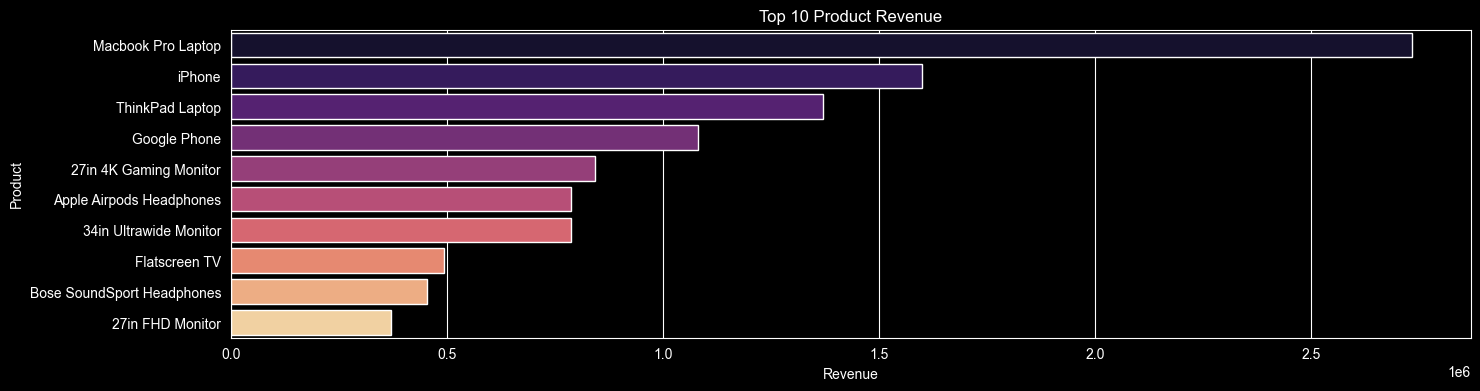

In [526]:
# Find Top 10 Product Revenue
df_product_revenue = df.groupby([df['Order Date'].dt.month, df['Product']])['Revenue'].sum().reset_index().rename(columns={'Order Date' : 'Month'})
top_10_product_oct_dec = df_product_revenue[df_product_revenue['Month'] >= 10].groupby(['Product'])['Revenue'].sum().nlargest(10).reset_index()

# Plot
plt.figure(figsize = (16, 4))
sns.barplot(top_10_product_oct_dec, y='Product', x='Revenue', palette='magma')
plt.title('Top 10 Product Revenue')
plt.show()

In [527]:
# Look for Most Paired in Purchase Products
from itertools import combinations
from collections import Counter

order_products = df.groupby('Order ID')['Product'].apply(list)
combos = Counter()
for prods in order_products:
    if len(prods) > 1:
        for pair in combinations(sorted(set(prods)), 2):
            combos[pair] += 1

print("Top Bundle Pairs:")
for pair, count in combos.most_common(5):
    print(f"  {pair[0]} + {pair[1]}: {count}x")

Top Bundle Pairs:
  Lightning Charging Cable + iPhone: 1011x
  Google Phone + USB-C Charging Cable: 997x
  Wired Headphones + iPhone: 462x
  Google Phone + Wired Headphones: 422x
  Apple Airpods Headphones + iPhone: 373x


**Findings**:
* Macbook Pro Laptop is the product that generates the most revenue, while 27in FHD Monitor is the opposite.
* For bundling, the recommended pairs are:
    * Macbook Pro Laptop + iPhone + Apple Airpods Headphones
        * Apple Ecosystem is one of the best, if not the best, in the world, therefore having the ecosystem bundled with a reduced aggregate price can potentially attract sales. Macbook Pro Laptop being the 1st revenue-generator, combined with iPhone in 2nd place can togetherly boost the sales of Apple Airpods Headphones that is currently ranked 6th.
    * iPhone + Apple Airpods Headphones
        * The combinations of these two is the 5th most bought together products with 373x transactions, bundling it together could boost more sales on both of these products
    * Google Phone + Bose SoundSport Headphones
        * While Google Phone actually paired with 'Wired Headphones', bundling it with Bose SoundSport Headphones instead can be considered since both falls in the same category of 'Headphones' and Bose SoundSport is ranked at 8th most purchased product in the last 3 months, which means there are demands for the headphone.

## Question 4
* Identifikasi top 5 kota yang memiliki order terbanyak dan 5 kota yang memiliki total dan rata-rata spending terbesar.


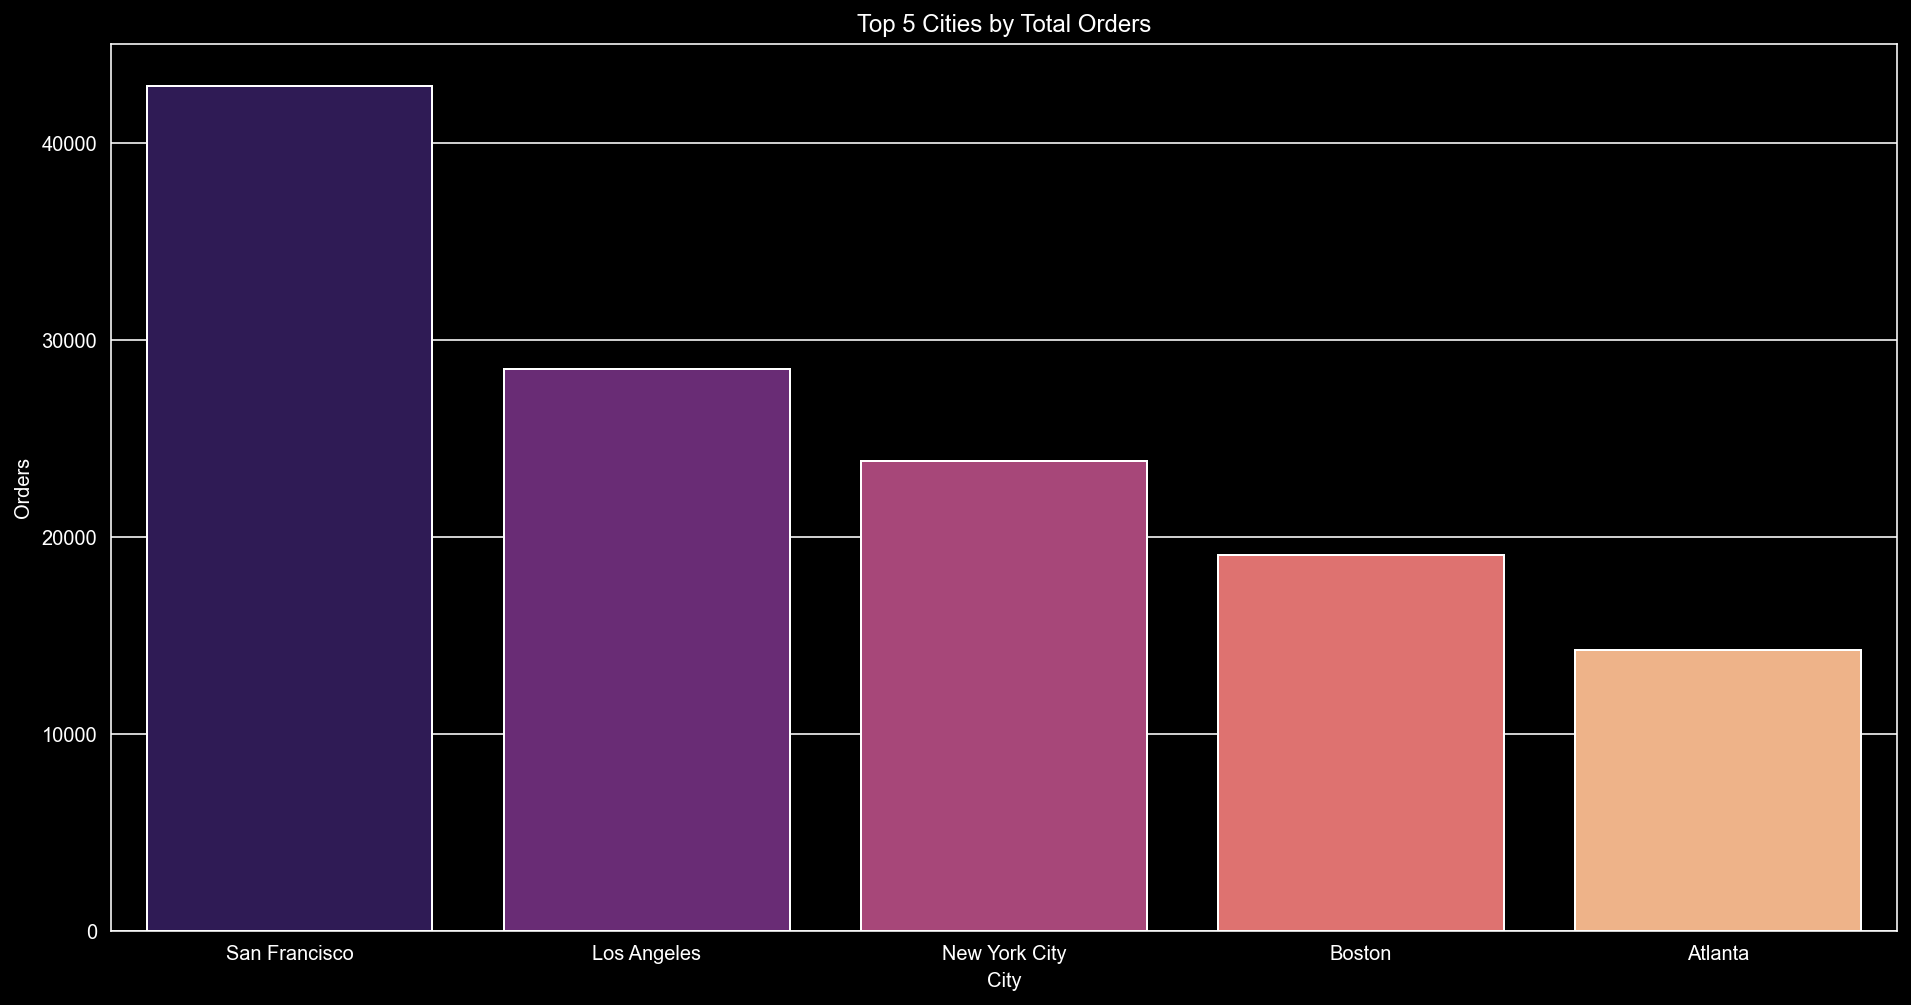

In [528]:
# # Top 5 Orders Cities
top_5_orders_cities = df.groupby('City')['Order ID'].nunique().nlargest(5).reset_index().rename(columns={'Order ID' : 'Total Orders'})

# Plot
plt.figure(figsize=(16, 8), frameon=True, dpi=144)
sns.barplot(top_5_orders_cities, x='City', y='Total Orders', palette='magma')
plt.title('Top 5 Cities by Total Orders')
plt.xlabel('City')
plt.ylabel('Orders')
plt.tight_layout
plt.show()

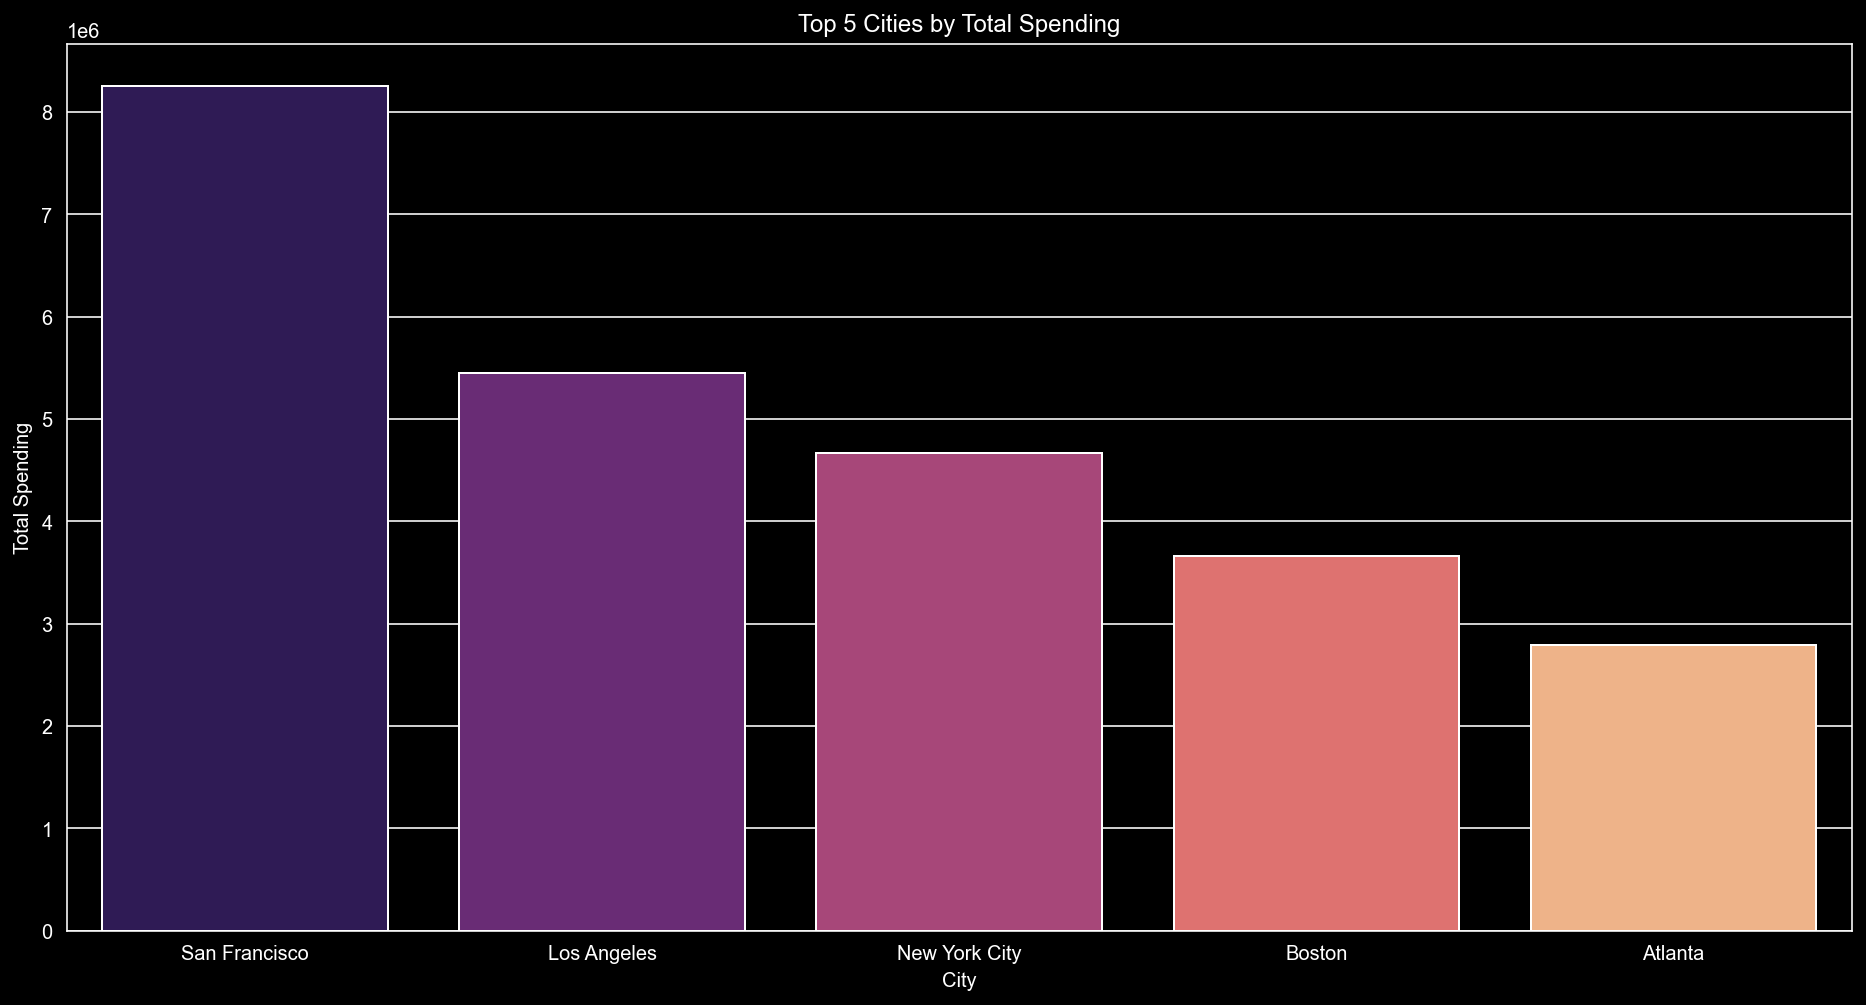

In [529]:
# Top 5 Total Spending Cities
top_5_total_spending_cities = df.groupby('City')['Revenue'].sum().nlargest(5).reset_index().rename(columns={'Revenue' : 'Total Spending'})

# Plot
plt.figure(figsize=(16, 8), frameon=True, dpi=144)
sns.barplot(top_5_total_spending_cities, x='City', y='Total Spending', palette='magma')
plt.title('Top 5 Cities by Total Spending')
plt.xlabel('City')
plt.ylabel('Total Spending')
plt.tight_layout
plt.show()

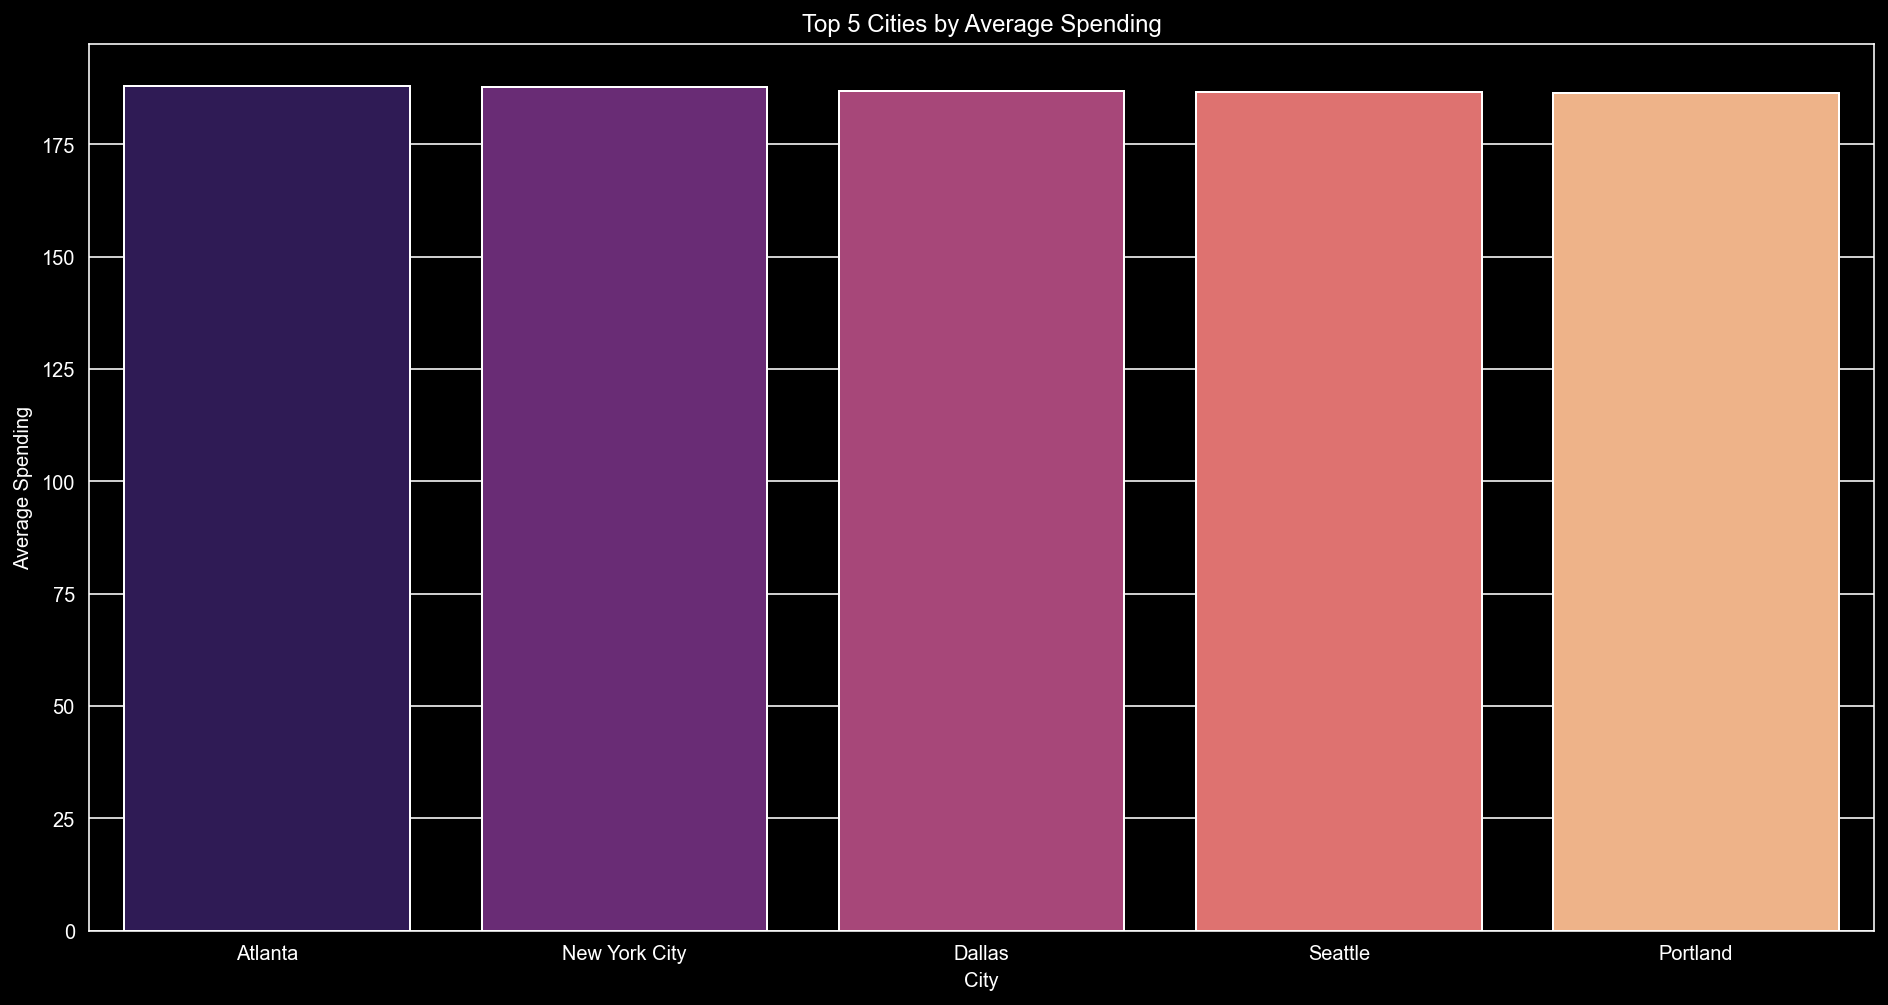

In [530]:
# Top 5 Average Spending Cities
top_5_avg_spending_cities = (
    (df.groupby('City')['Revenue'].mean().nlargest(5).reset_index().rename(columns={'Revenue': 'Average Spending'})))

# Plot
plt.figure(figsize=(16, 8), frameon=True, dpi=144)
sns.barplot(top_5_avg_spending_cities, x='City', y='Average Spending', palette='magma')
plt.title('Top 5 Cities by Average Spending')
plt.xlabel('City')
plt.ylabel('Average Spending')
plt.tight_layout
plt.show()

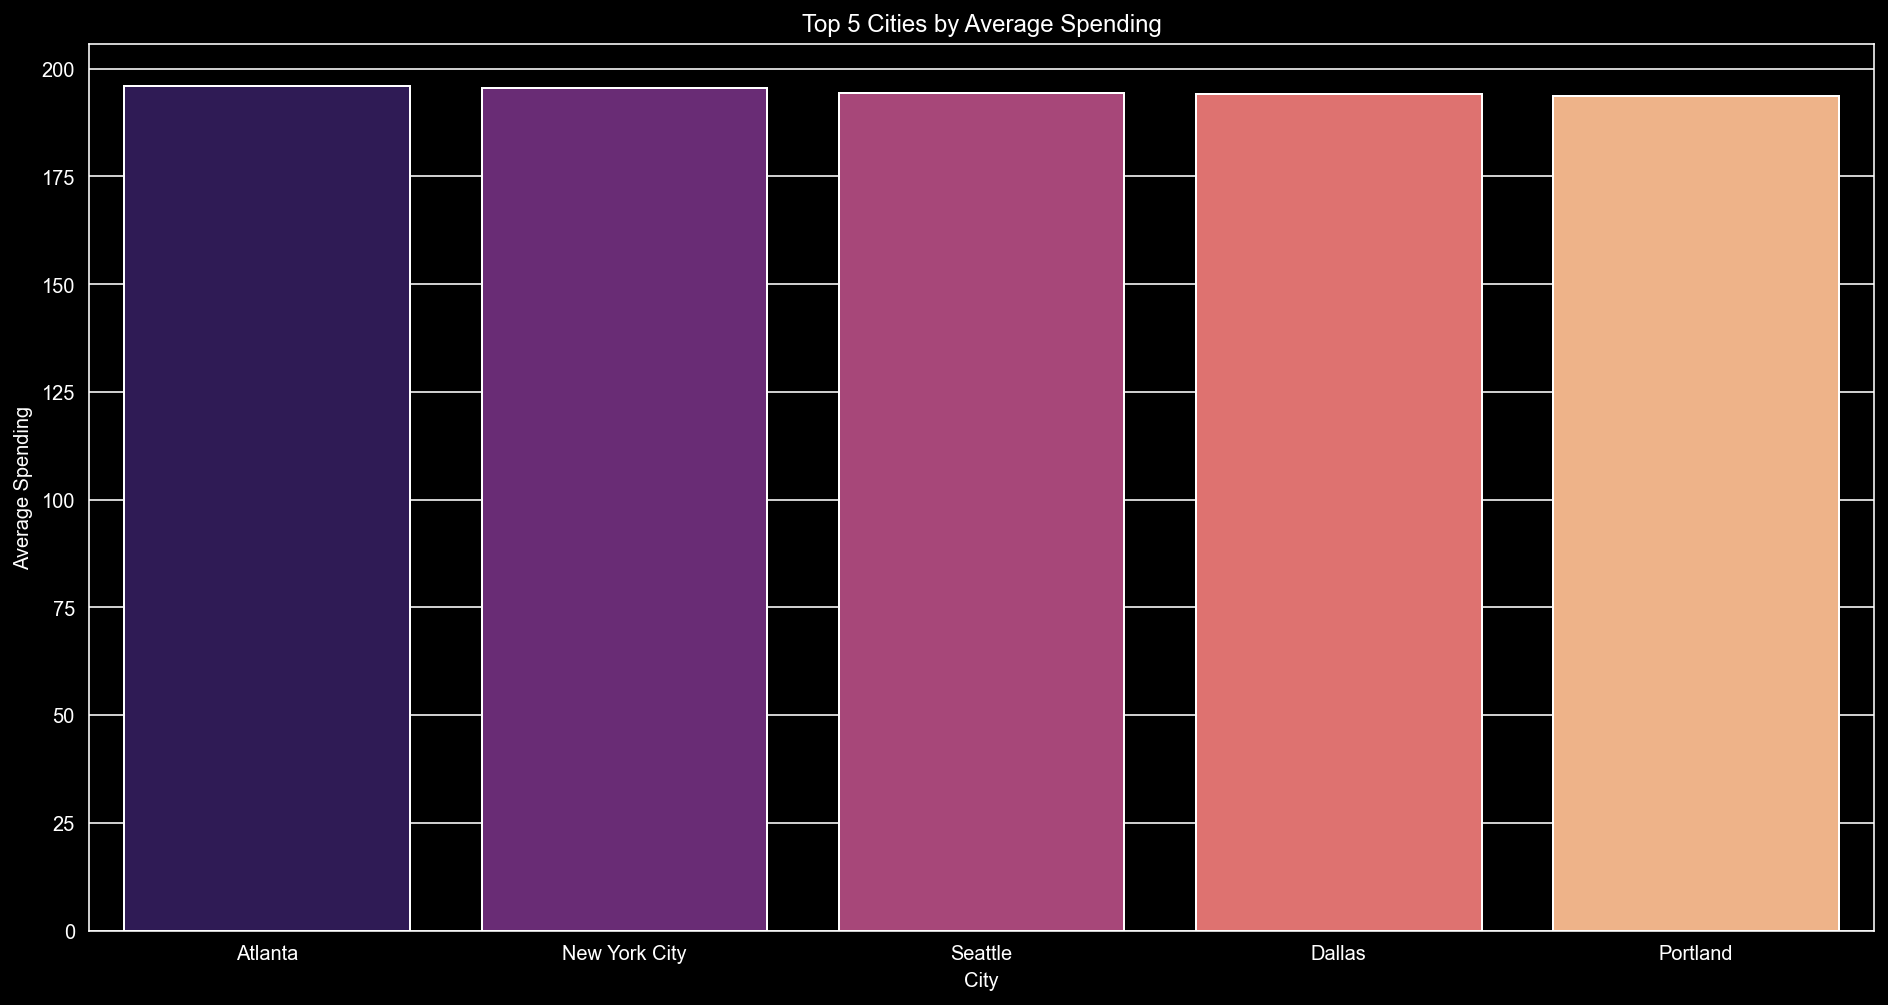

In [531]:
# Top 5 Average Spending per Transaction Cities
top_5_avg_spending_trx_cities = (
    (df.groupby('City')['Revenue'].sum() / df.groupby('City')['Order ID'].nunique())
    .nlargest(5).reset_index()
    .rename(columns={0: 'Average Spending'})
)

# Plot
plt.figure(figsize=(16, 8), frameon=True, dpi=144)
sns.barplot(top_5_avg_spending_trx_cities, x='City', y='Average Spending', palette='magma')
plt.title('Top 5 Cities by Average Spending')
plt.xlabel('City')
plt.ylabel('Average Spending')
plt.tight_layout
plt.show()

**Findings**:
* San Francisco is the city with the most total orders and total spending in 2019, while Atlanta is the opposite.
* However, average spending city-wise and transaction-wise is the highest in Atlanta, despite being the 5th city with most orders and spending. This indicates that while SF is bigger in numbers, the average spending is lower than Atlanta, presumably caused by high volume of purchase on low-price goods.
* The difference between cities in average spending is minuscule and not easily distinguishable.

## Question 5
* Tim marketing ingin mengetahui kapan penjualan mencapai titik tertinggi sehingga mereka bisa merancang strategi marketing. Analisis rentang jam berapa penjualan terjadi secara aktif (rush hour).



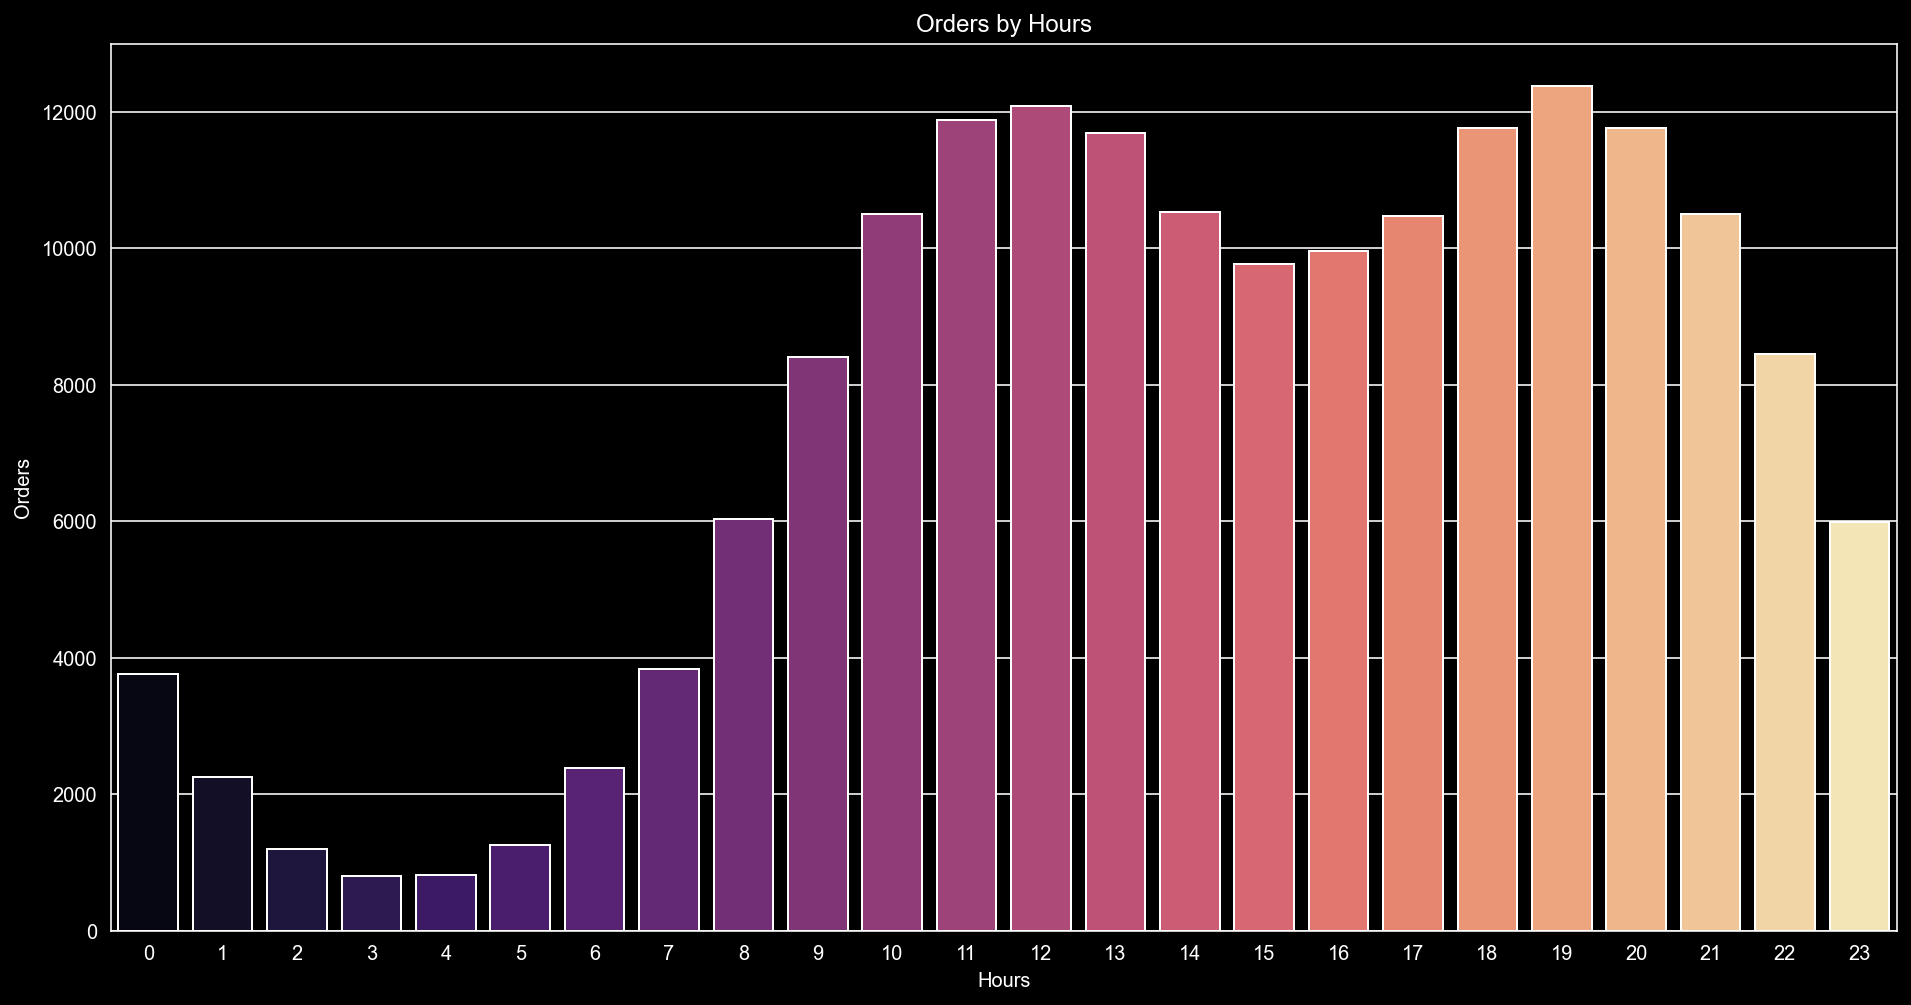

In [532]:
# Extract Hourly Orders
df_hourly = df.groupby(df['Order Date'].dt.hour)['Order ID'].nunique().reset_index().rename(columns={'Order ID' : 'Total Orders', 'Order Date' : 'Hour'})

# Plot
plt.figure(figsize=(16, 8), frameon=True, dpi=144)
sns.barplot(df_hourly, x='Hour', y='Total Orders', palette='magma')
plt.title('Orders by Hours')
plt.xlabel('Hours')
plt.ylabel('Orders')
plt.tight_layout
plt.show()

**Findings**:
* Most of the orders are concentrated in **mid-day/noon hours (11.00-13.00) and evening hours (18.00-20.00)**, where the latter have more volume of orders.
* The low volume of orders during the range of 00.00 - 07.00 is reasonable since during these hours **people rarely active outside**. However, this also indicates that the store is open for 24 hours, allowing midnight to dawn purchases.

## Question 6
* Buatlah model forecasting menggunakan model yang sudah diajarkan pada materi untuk memprediksi jumlah visitor dan jumlah transaksi untuk 1 bulan ke depan dengan data harian. Anda diharuskan setidaknya membuat 2 model untuk selanjutnya diambil model terbaik berdasarkan MAE terkecil. Berikan rekomendasi apa yang perlu dilakukan tim bisnis berdasarkan hasil forecasting dan analisis Anda.

### Train Test Split

In [533]:
train = ts_orders[:-30]
test  = ts_orders[-30:]

### Prophet

21:07:14 - cmdstanpy - INFO - Chain [1] start processing
21:07:14 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 73.38


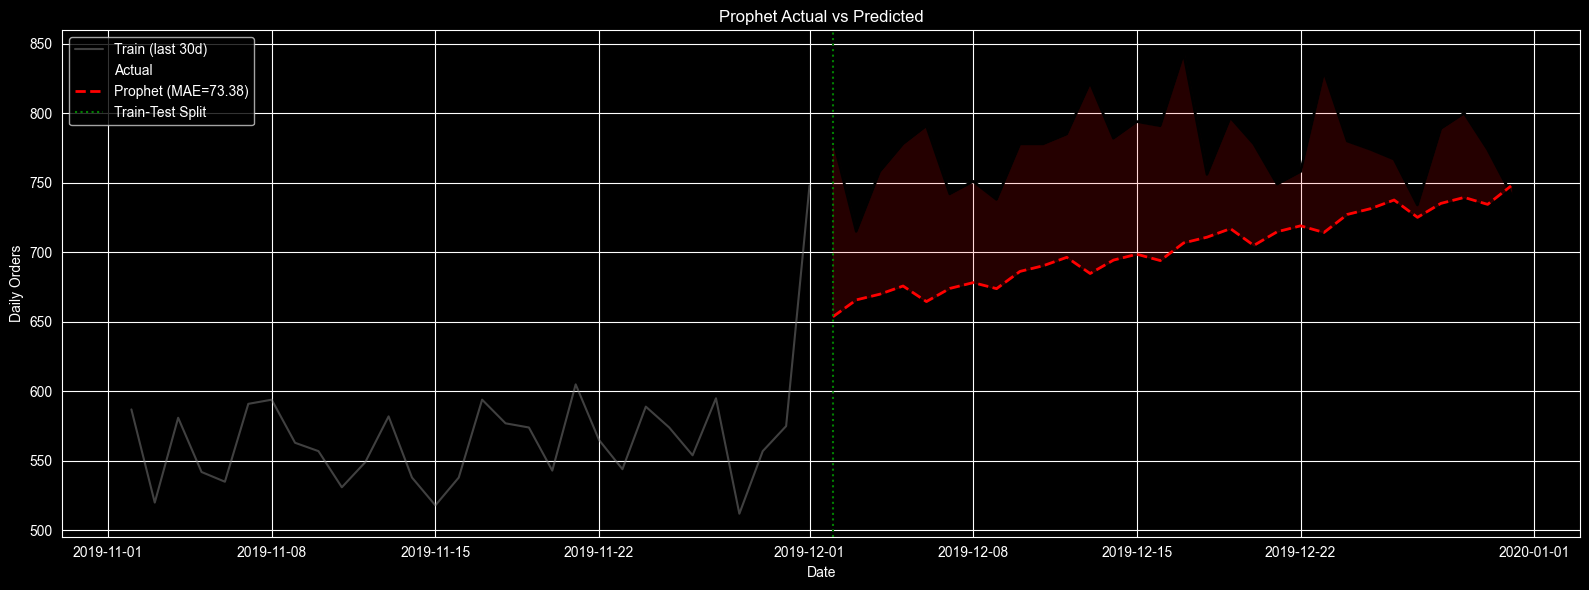

In [534]:
# Preparation
df_prophet = ts_orders.reset_index()
df_prophet.columns = ['ds', 'y']

# Train-Test Split
train_p = df_prophet[:-30]
test_p  = df_prophet[-30:]

# Model
model_prophet = Prophet(
    seasonality_mode='multiplicative',
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.15
)
model_prophet.add_country_holidays(country_name='US')
model_prophet.fit(train_p)

# Forecast
future = model_prophet.make_future_dataframe(periods=30)
forecast_prophet = model_prophet.predict(future)
pred_p = forecast_prophet['yhat'].values[-30:]

# Evaluate
mae_prophet = mean_absolute_error(test_p['y'].values, pred_p)
print(f"Prophet MAE: {mae_prophet:.2f}")

# Forecast vs Actual
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(train_p['ds'].values[-30:], train_p['y'].values[-30:],
        label='Train (last 30d)', color='gray', alpha=0.5)
ax.plot(test_p['ds'].values, test_p['y'].values,
        label='Actual', color='black', linewidth=2)
ax.plot(test_p['ds'].values, pred_p,
        label=f'Prophet (MAE={mae_prophet:.2f})', color='red', linewidth=2, linestyle='--')
ax.fill_between(test_p['ds'].values, test_p['y'].values, pred_p, alpha=0.15, color='red')
ax.axvline(x=test_p['ds'].values[0], color='green', linestyle=':', label='Train-Test Split')
ax.set_title('Prophet Actual vs Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Orders')
ax.legend()
plt.tight_layout()
plt.show()


### Gated-Recurrent Units (GRU)

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_12 (GRU)                    │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0343 - val_loss: 0.0052
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0103 - val_loss: 0.0229
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0077 - val_loss: 0.0060
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0067 - val_loss: 0.0089
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0059 - val_loss: 0.0056
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0058 - val_loss: 0.0049
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0048 - val_loss: 0.0053
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0055 - val_loss: 0.0051
Epoch 9/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 10/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0057 - val_loss: 0.0057
Epoch 11/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0053 - val_loss: 0.0049
Epoch 12/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

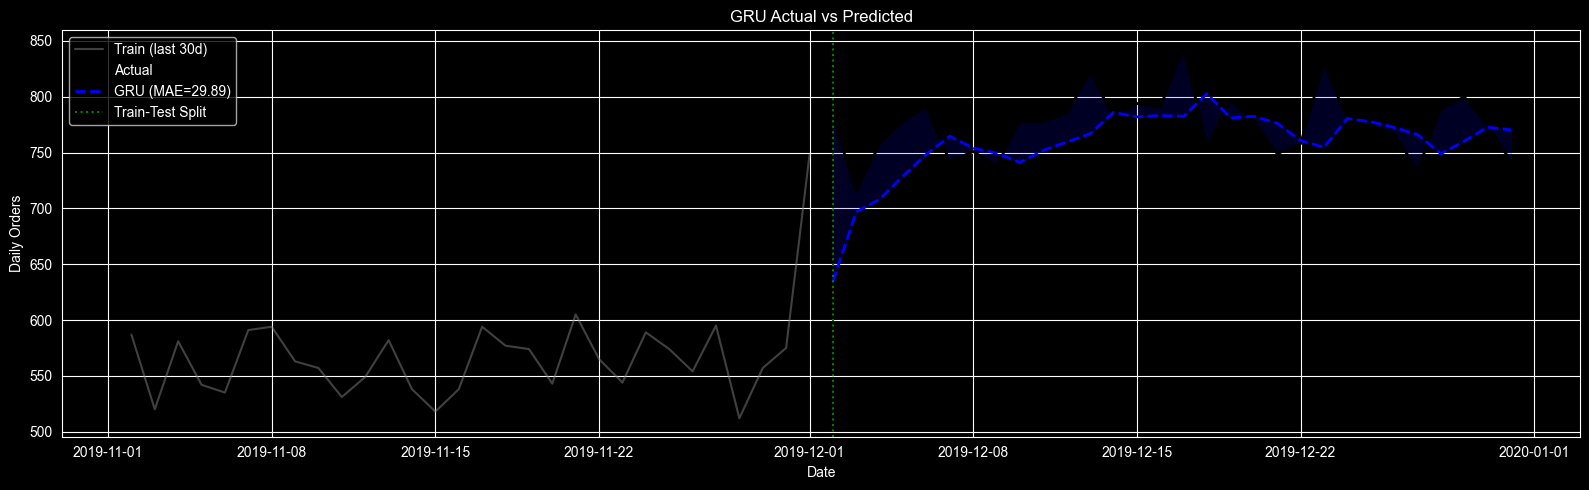

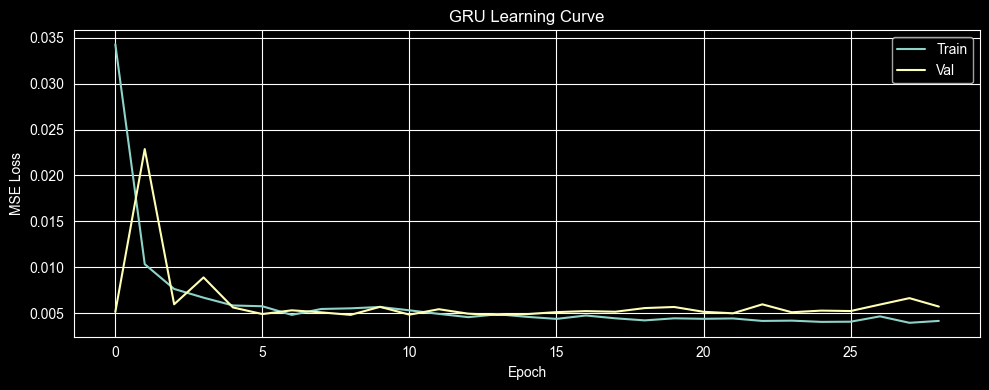

In [539]:
# Preparation
values = ts_orders.values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)
train_scaled = scaled[:-30]
test_scaled = scaled[-30:]
window = 14
full_scaled = np.concatenate([train_scaled, test_scaled])

# Sequence Generation
X_train, y_train = [], []
for i in range(window, len(train_scaled)):
    X_train.append(train_scaled[i-window:i, 0])
    y_train.append(train_scaled[i, 0])

X_test, y_test = [], []
for i in range(len(train_scaled), len(full_scaled)):
    X_test.append(full_scaled[i-window:i, 0])
    y_test.append(full_scaled[i, 0])

# Train Test Split for GRU
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

X_test, y_test = np.array(X_test), np.array(y_test)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# GRU Model
model_gru = Sequential([
    GRU(32, input_shape=(window, 1), return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)])

model_gru.compile(optimizer='adam', loss='mse')
model_gru.summary()

early_stop_gru = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True)

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.15,
    callbacks=[early_stop_gru],
    verbose=1)

# Forecast
pred_gru_scaled = model_gru.predict(X_test)
pred_gru = scaler.inverse_transform(pred_gru_scaled).flatten()
actual_gru = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae_gru = mean_absolute_error(actual_gru, pred_gru)
print(f"GRU MAE: {mae_gru:.2f}")

# Actual vs Predicted
plt.figure(figsize=(16, 5))
plt.plot(train.index[-30:], train.values[-30:], label='Train (last 30d)', color='gray', alpha=0.5)
plt.plot(test.index, actual_gru, label='Actual', color='black', linewidth=2)
plt.plot(test.index, pred_gru, label=f'GRU (MAE={mae_gru:.2f})', color='blue', linewidth=2, linestyle='--')
plt.fill_between(test.index, actual_gru, pred_gru, alpha=0.15, color='blue')
plt.axvline(x=test.index[0], color='green', linestyle=':', label='Train-Test Split')
plt.title('GRU Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Daily Orders')
plt.legend()
plt.tight_layout()
plt.show()

# Learning Curve
plt.figure(figsize=(10, 4))
plt.plot(history_gru.history['loss'], label='Train')
plt.plot(history_gru.history['val_loss'], label='Val')
plt.title('GRU Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Model Discussion
According to the two models above, it can be concluded that **Gated-Recurrent Units (GRU) performs better with significantly smaller Mean Absolute Error (MAE) at 29.89**, compared to the higher MAE of Prophet model at 73.38. The Prophet model performance is limited by the **fixed seasonal patterns from the decomposition process**, incorporating the assumptions on trend, seasonality, and holidays factors (US Holidays are included which gives the relatively good MAE in the given result). In a case of limited dataset of merely 1 year, which isn't enough, **the patterns aren't sufficient for the model to learns possible abnormalities**. Therefore, the abnormalities of trend spike in December is not captured which results in the higher MAE than GRU. <br>

Conversely, GRU learns from the window period of 14 days given in the parameters above, without any incorporation of decomposed trend, seasonality, and holidays alike Prophet. This way, **GRU is more sensitive to recent patterns, such as the growth in November that has been happening since October**. This way, **the spike in December can be predicted more accurately**. Hence, the MAE result is smaller and the pattern is closer to the actual data. <br>

For a while, GRU is the winner. However, **due to its recursive forecasting framework, GRU might fall off in performance to Prophet**. The decomposition process of Prophet gathers the trend, seasonality, and holidays factors to its forecasting method. **Therefore, the pattern in January 2019 may exhibit a similar form in January 2020, and Prophet presumably is able to capture that in its result**.|

### January 2020 Forecast

#### Prophet

21:07:24 - cmdstanpy - INFO - Chain [1] start processing
21:07:24 - cmdstanpy - INFO - Chain [1] done processing


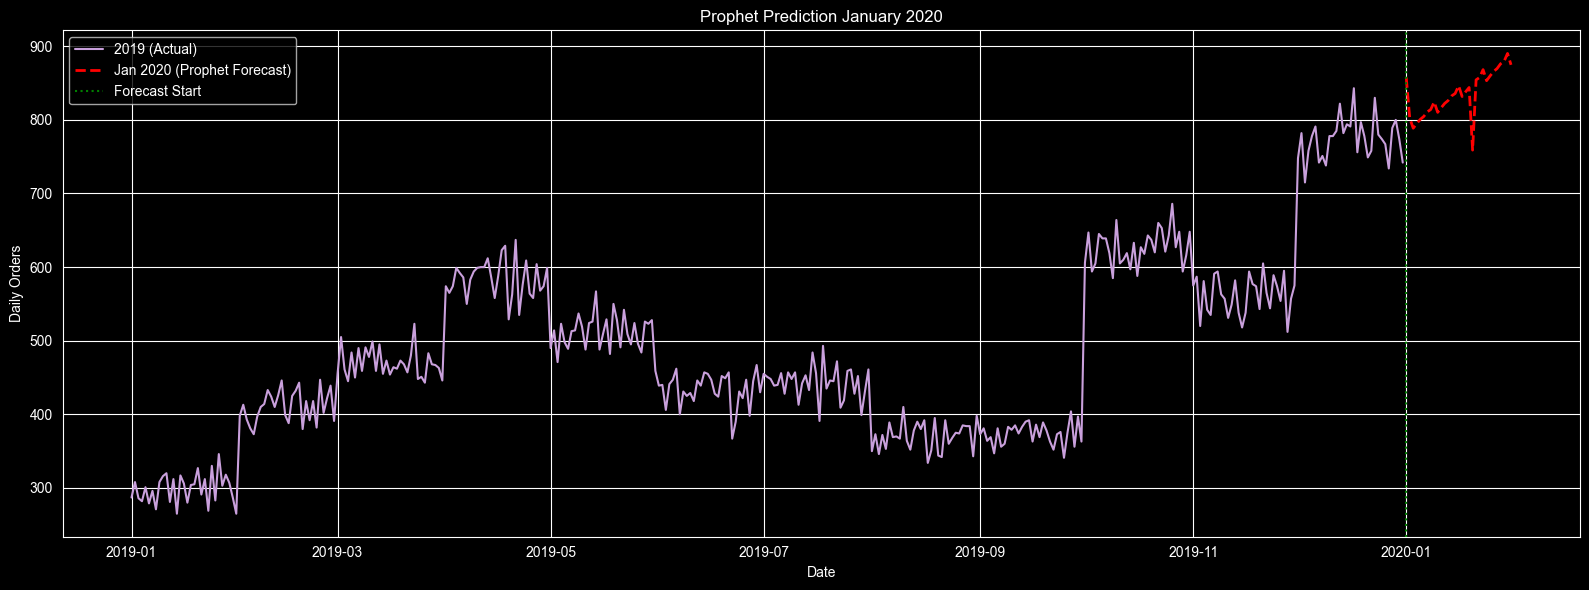

In [536]:
# Preparation
df_prophet_full = ts_orders.reset_index()
df_prophet_full.columns = ['ds', 'y']

# Model, Retrain Completely on 2019 Data
model_prophet_full = Prophet(
    seasonality_mode='multiplicative',
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.15
)
model_prophet_full.add_country_holidays(country_name='US')
model_prophet_full.fit(df_prophet_full)

# Forecast on January 2020
future_full = model_prophet_full.make_future_dataframe(periods=31)
forecast_full = model_prophet_full.predict(future_full)
pred_jan_prophet = forecast_full['yhat'].values[-31:]
jan_dates_prophet = forecast_full['ds'].values[-31:]

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_prophet_full['ds'].values, df_prophet_full['y'].values,
        label='2019 (Actual)', color='#C9A0DC', linewidth=1.5)
ax.plot(jan_dates_prophet, pred_jan_prophet,
        label='Jan 2020 (Prophet Forecast)', color='red', linewidth=2, linestyle='--')
ax.axvline(x=jan_dates_prophet[0], color='green', linestyle=':', label='Forecast Start')
ax.set_title('Prophet Prediction January 2020')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Orders')
ax.legend()
plt.tight_layout()
plt.show()

#### GRU

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0845 - val_loss: 0.1551
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0156 - val_loss: 0.0866
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0114 - val_loss: 0.0516
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0089 - val_loss: 0.0483
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0068 - val_loss: 0.0268
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0058 - val_loss: 0.0212
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0060 - val_loss: 0.0157
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0056 - val_loss: 0.0133
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0051 - val_loss: 0.0105
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0053 - val_loss: 0.0107
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0047 - val_loss: 0.0125
Epoch 12/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - los

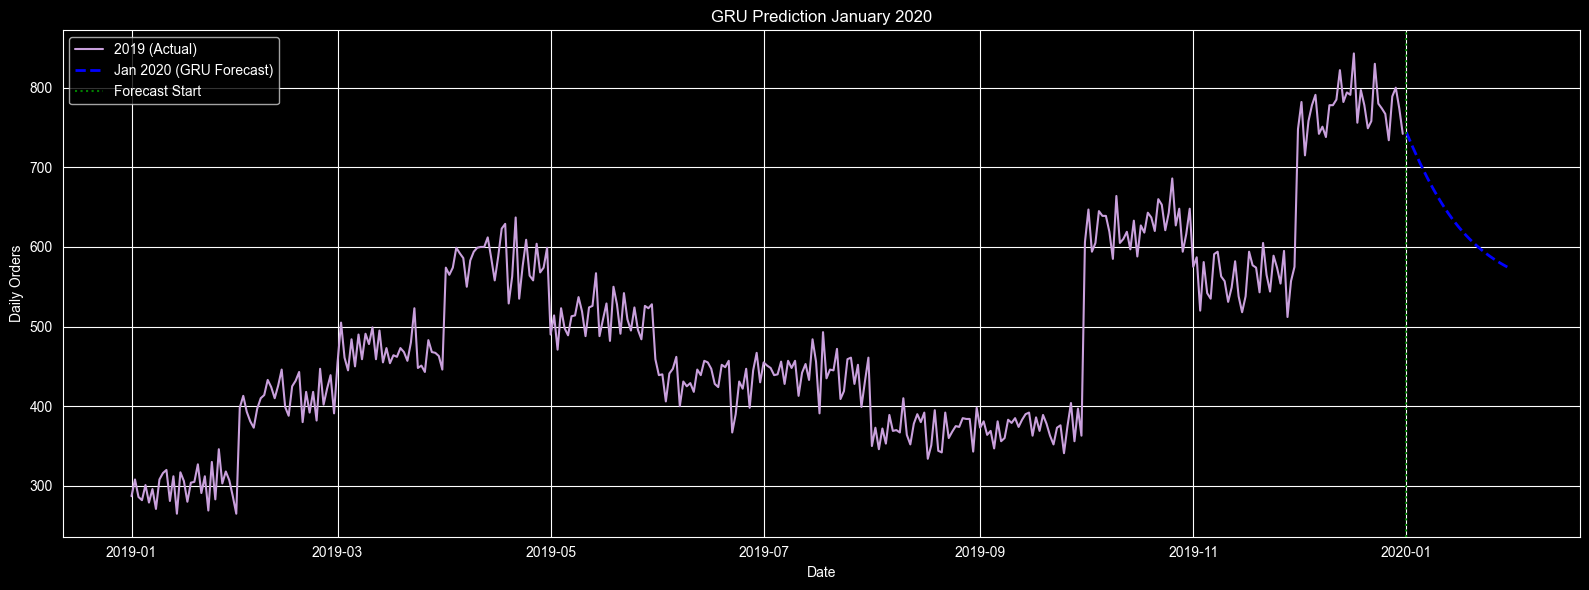

In [537]:
# Preparation
values_full = ts_orders.values.reshape(-1, 1)
scaler_full = MinMaxScaler()
scaled_full = scaler_full.fit_transform(values_full)

X_full, y_full = [], []
for i in range(window, len(scaled_full)):
    X_full.append(scaled_full[i-window:i, 0])
    y_full.append(scaled_full[i, 0])

X_full, y_full = np.array(X_full), np.array(y_full)
X_full = X_full.reshape(X_full.shape[0], X_full.shape[1], 1)

# Model, Retrain Completely on 2019 Data
model_gru_full = Sequential([
    GRU(32, input_shape=(window, 1), return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_gru_full.compile(optimizer='adam', loss='mse')

early_stop_full = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True)

history_gru_full = model_gru_full.fit(
    X_full, y_full,
    epochs=200,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop_full],
    verbose=1)

# Recursive Forecast on January 2020
last_window = scaled_full[-window:].flatten().tolist()
predictions = []

for _ in range(31):
    input_seq = np.array(last_window[-window:]).reshape(1, window, 1)
    pred = model_gru_full.predict(input_seq, verbose=0)[0, 0]
    predictions.append(pred)
    last_window.append(pred)

pred_jan_gru = scaler_full.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
jan_dates = pd.date_range('2020-01-01', periods=31, freq='D')

# Plot
plt.figure(figsize=(16, 6))
plt.plot(ts_orders.index, ts_orders.values,
         label='2019 (Actual)', color='#C9A0DC', linewidth=1.5)
plt.plot(jan_dates, pred_jan_gru,
         label='Jan 2020 (GRU Forecast)', color='blue', linewidth=2, linestyle='--')
plt.axvline(x=jan_dates[0], color='green', linestyle=':', label='Forecast Start')
plt.title('GRU Prediction January 2020')
plt.xlabel('Date')
plt.ylabel('Daily Orders')
plt.legend()
plt.tight_layout()
plt.show()

#### Model Conclusion
From the result above, it can be seen that **Prophet performs significantly better** by being able to capture the seasonality pattern of January 2019 to January 2020, though not having the closest resemblance. Compared to GRU's, the result is far worse than expected. The forecasting result only **exhibit a decaying line rather than a fluctuating pattern** which is apparent on January 2019 data, likely due to its recursive forecasting method where to the end of December, the volume of orders are depleting. Therefore, it's clear that **Prophet model is preferred for January 2020 forecasting**. <br>

Based on the forecasting result by Prophet, the **volume of orders tend to grow significantly** compared to last year record. However, there's a **possibility for a trench-like volume drop in the third-week of January 2020**. It's advised to monitor for daily volume of orders and compare the deviation to forecasting result to allow for earlier anticipation say the presumed trench-like drop occurs. <br>

Additionally, without any visitors data, it can't be forecasted how many visitors would come to the store (both those who decide to buy and not). Therefore, it can be assumed that, at least, the number of visitors would be equal to or slightly more than the volume of orders.